<a href="https://colab.research.google.com/github/JediricX/desercionIA/blob/main/Detecci%C3%B3n_temprana_abandono_universitario_Tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Modelo IA para la detección temprana del abandono universitario basado en dataset OULAD

Objetivo del modelo:

Diseñar e implementar un Sistema de Alerta Temprana basado en Inteligencia Artificial que permita predecir el riesgo de abandono en programas universitarios a distancia, mediante la comparación de algoritmos de clasificación supervisada (Random Forest, Árboles de Decisión, XGBoost y Regresión Logística), con el fin de ofrecer a las instituciones educativas una herramienta preventiva para la retención estudiantil.

Autores:


*   Richard Humberto Campos Ballesteros
*   José Andía



# **1. Importación de librerías**

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np
import os

# Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import RocCurveDisplay

# Desbalance de clases
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# **2. Carga del dataset OULAD**

In [2]:
# Install dependencies as needed:
#!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

#Assessments
assessments = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "assessments.csv"
)

#Courses
courses = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "courses.csv"
)

#student_assessment
student_assessments = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "studentAssessment.csv"
)

#student_info
student_info = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "studentInfo.csv"
)

#student_registration
student_registration = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "studentRegistration.csv"
)

#vle
vle = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "vle.csv"
)

#student_vle
student_vle = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "studentVle.csv"
)


/tmp/ipykernel_3862/3950185065.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  assessments = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.


/tmp/ipykernel_3862/3950185065.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  courses = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.


/tmp/ipykernel_3862/3950185065.py:21: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  student_assessments = kagglehub.load_dataset(


...

Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.


/tmp/ipykernel_3862/3950185065.py:42: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  vle = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.


/tmp/ipykernel_3862/3950185065.py:49: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  student_vle = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.


# **3. Fase de análisis de datos (EDA)**

### 3.1. Descripción general de los datasets

--- Assessments DataFrame ---
Shape: (206, 6)
Head:
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               195 non-nul

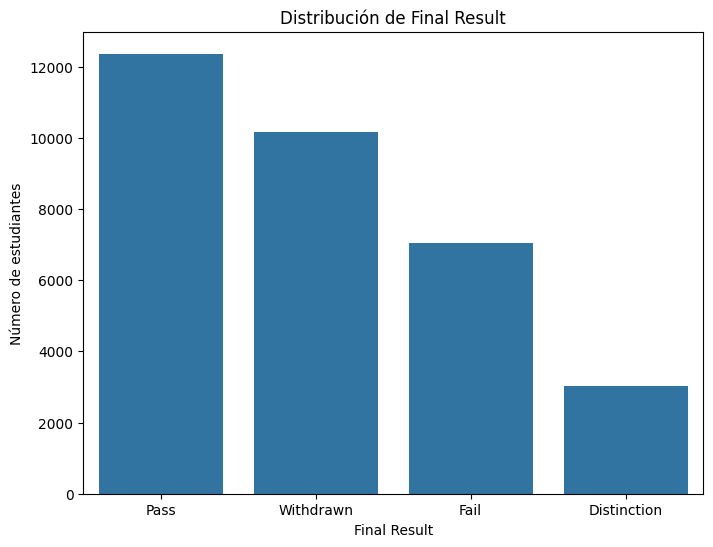


Basado en el objetivo ('abandono'), 'Withdrawn' es la salida clave para la predicción.

### 3.3. Exploración de variable clave y uniones iniciales para predicción temprana
#### 3.3.1. Fusionando información y registro de estudiantes
Encabezado del dataset fusionado 'student_data' (student_info + student_registration):

  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equ

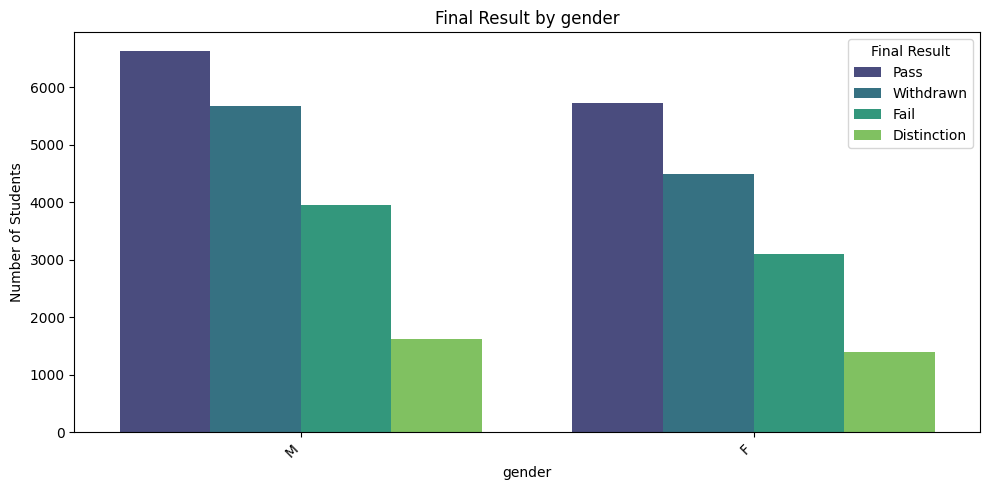

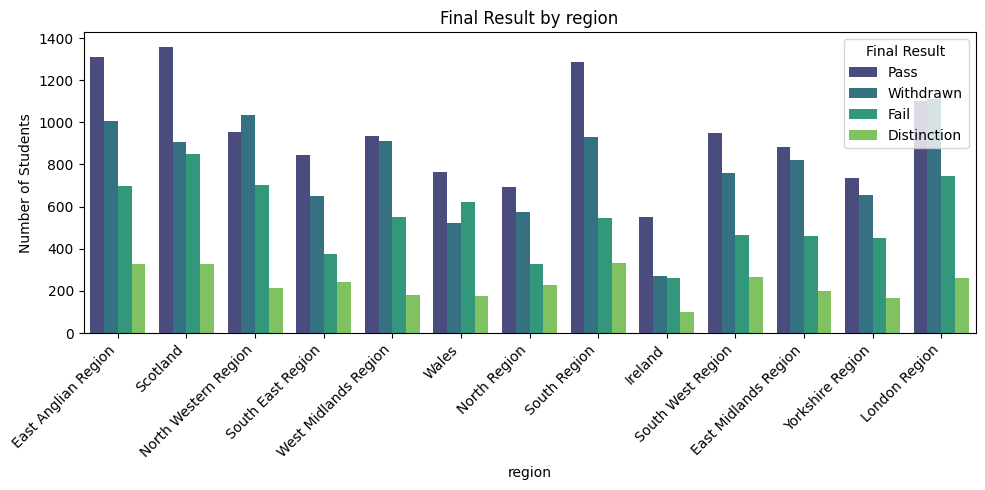

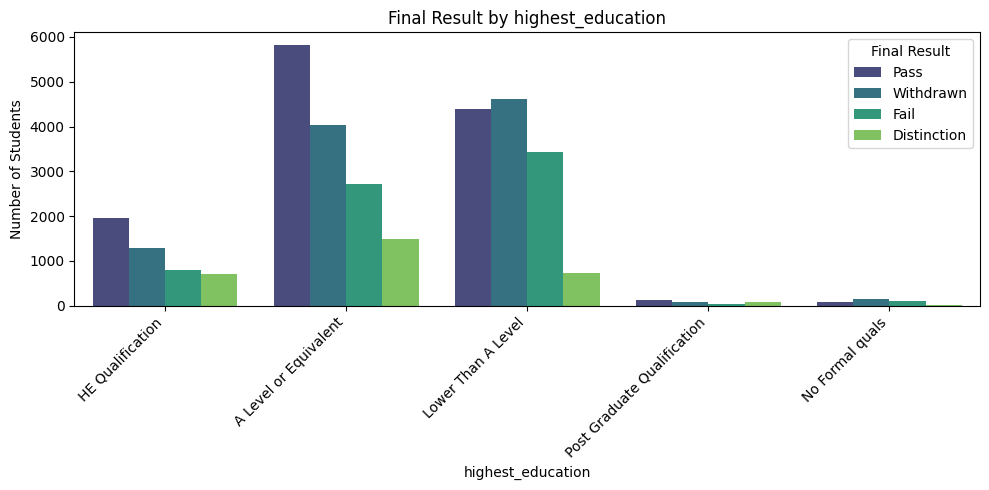

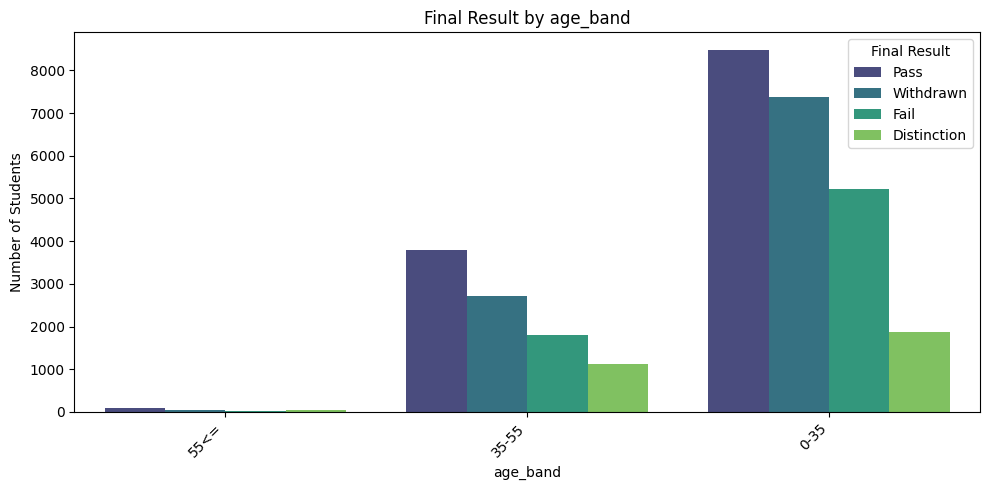

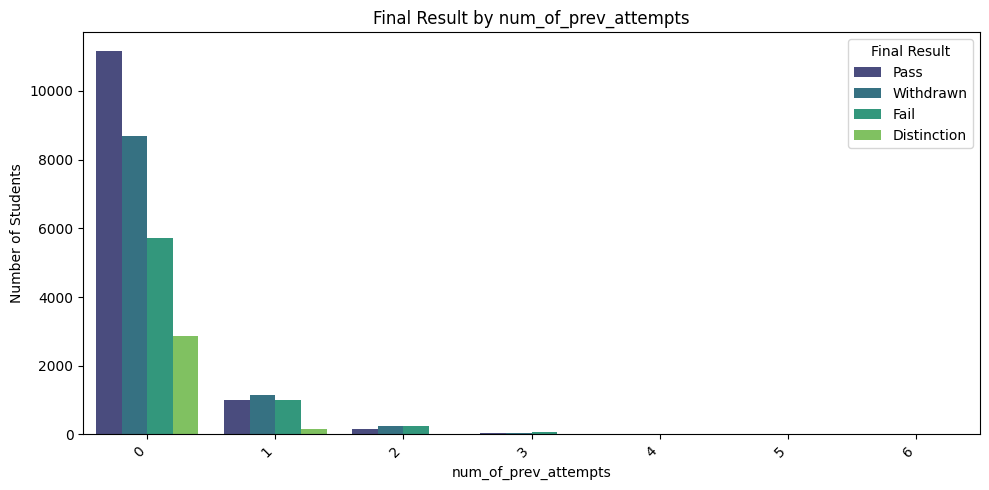

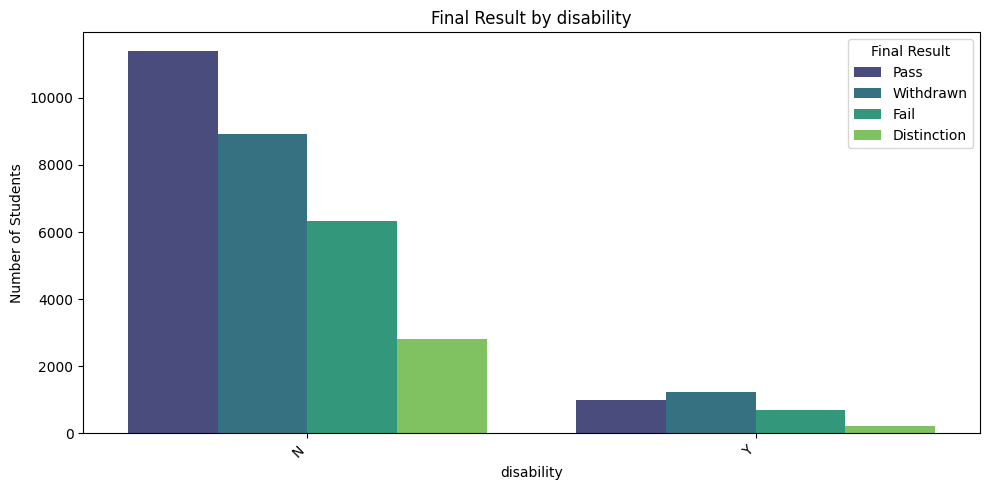

/tmp/ipykernel_3862/2395957638.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_data, x='final_result', y='studied_credits', palette='viridis')


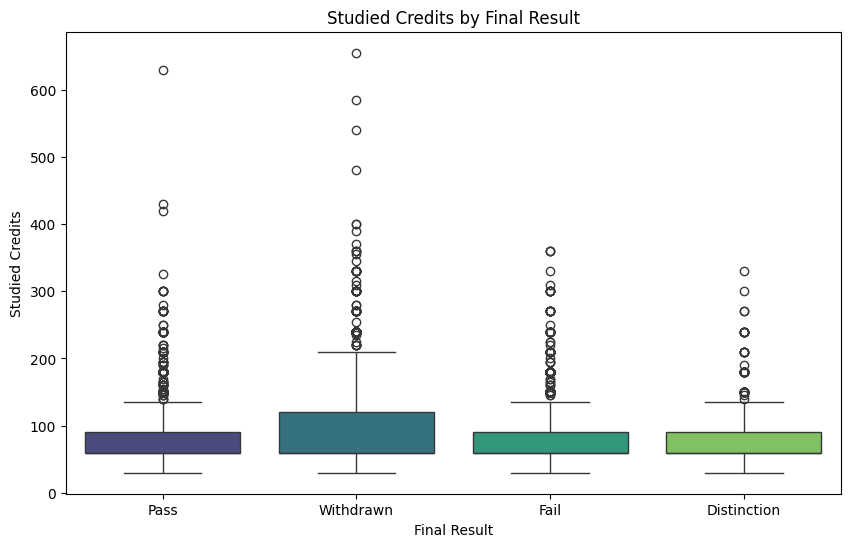


#### 3.3.3. Analizando datos de registro (`date_registration`)


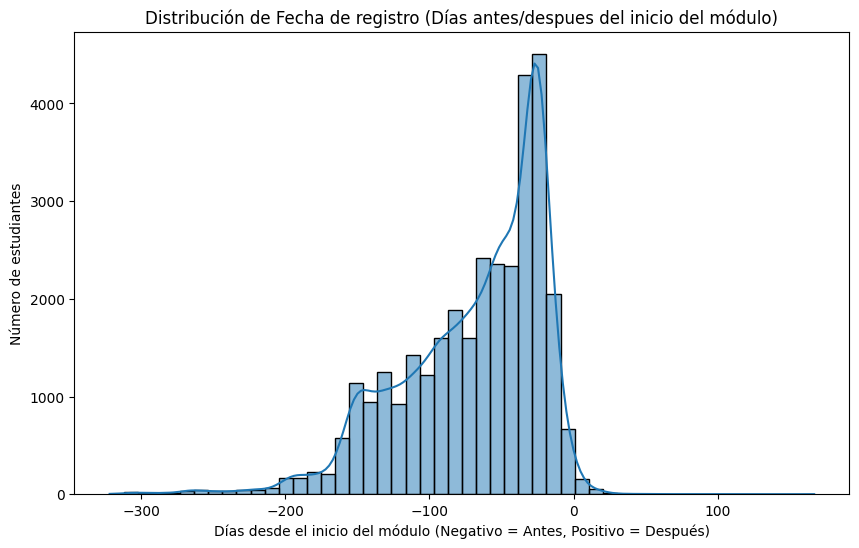

/tmp/ipykernel_3862/2395957638.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_data, x='final_result', y='date_registration', palette='viridis')


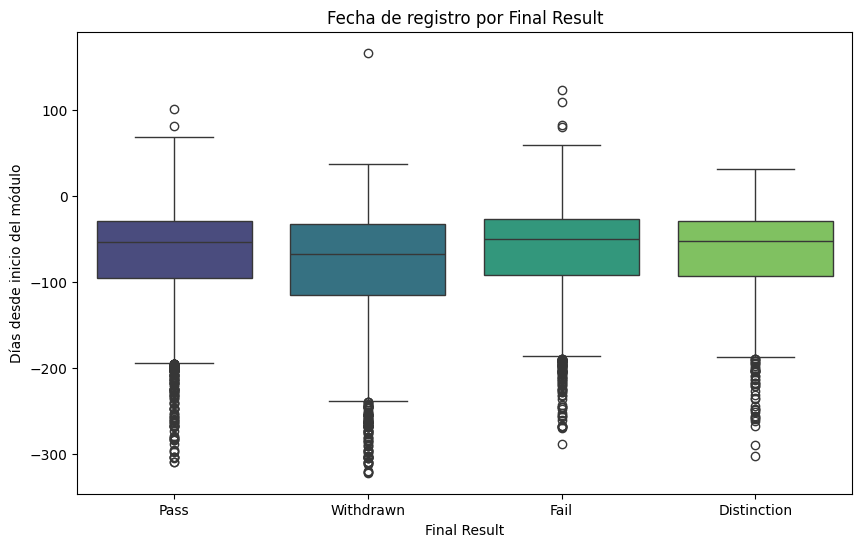


#### 3.3.4. Explorando el desempeño de la evaluación temprana
Encabezado de 'full_assessment_data':
  code_module code_presentation  id_student gender               region  \
0         AAA             2013J       11391      M  East Anglian Region   
1         AAA             2013J       11391      M  East Anglian Region   
2         AAA             2013J       11391      M  East Anglian Region   
3         AAA             2013J       11391      M  East Anglian Region   
4         AAA             2013J       11391      M  East Anglian Region   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification  90-100%     55<=                     0              240   
2  HE Qualification  90-100%     55<=                     0              240   
3  HE Qualification  90-100%     55<=                     0              240   
4  HE Qualification  90-100%     55<=           

/tmp/ipykernel_3862/2395957638.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_data, x='final_result', y='early_avg_score', palette='viridis')


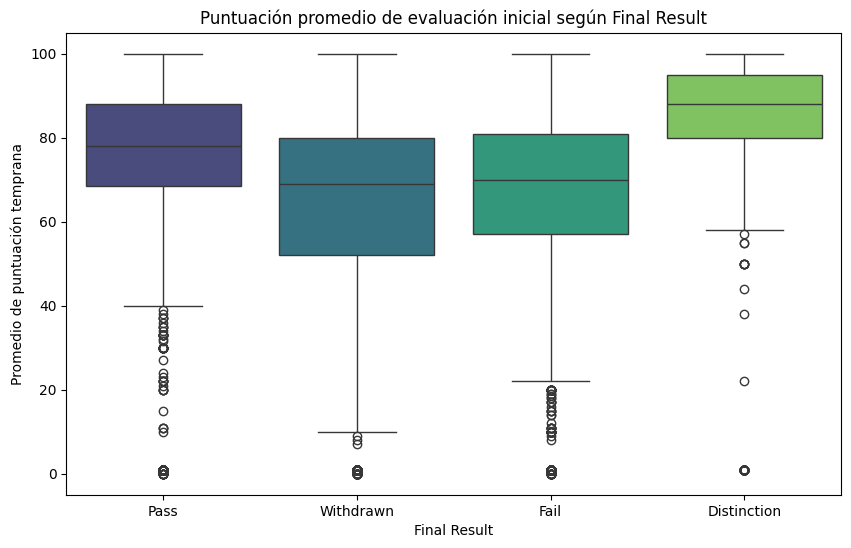


#### 3.3.5. Explorando Actividad VLE temprana
Encabezado de 'full_vle_data':
  code_module code_presentation  id_student gender               region  \
0         AAA             2013J       11391      M  East Anglian Region   
1         AAA             2013J       11391      M  East Anglian Region   
2         AAA             2013J       11391      M  East Anglian Region   
3         AAA             2013J       11391      M  East Anglian Region   
4         AAA             2013J       11391      M  East Anglian Region   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification  90-100%     55<=                     0              240   
2  HE Qualification  90-100%     55<=                     0              240   
3  HE Qualification  90-100%     55<=                     0              240   
4  HE Qualification  90-100%     55<=                     0            

/tmp/ipykernel_3862/2395957638.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_data, x='final_result', y='early_total_clicks', palette='viridis')


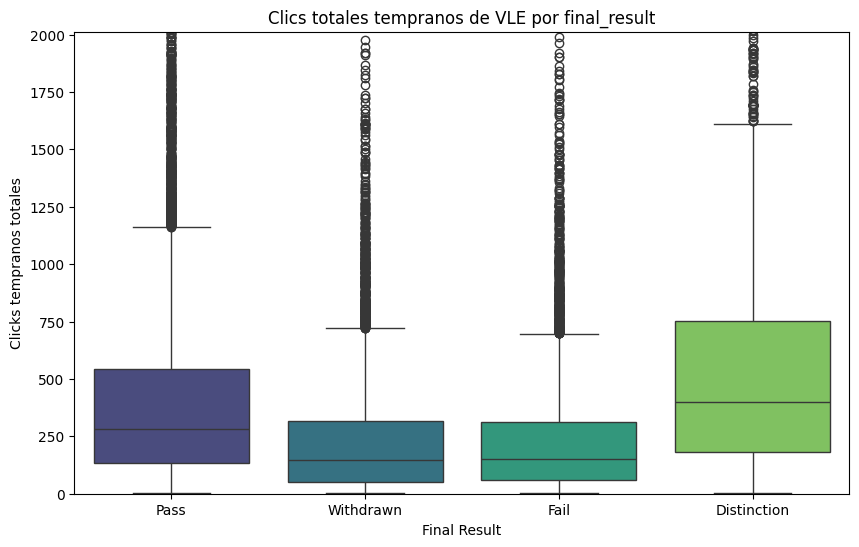


--- EDA Summary and Key Variables for Early Prediction ---
Variables identified as potentially important for early prediction include:
- **Demographic and Background:** gender, region, highest_education, age_band, num_of_prev_attempts, disability, studied_credits. These are available at the start.
- **Registration Behavior:** `date_registration` (how early/late a student registers). This is an early indicator.
- **Early Assessment Performance:** Average scores from assessments taken in the first few weeks/months. This requires monitoring initial academic engagement.
- **Early VLE Engagement:** Total clicks or activity types within the Virtual Learning Environment during the initial period of the course. This also requires monitoring early activity.

Further steps would involve more detailed feature engineering from these raw variables, handling missing values, and preparing the data for model training.


In [3]:
print("### 3.1. Descripción general de los datasets")

# Función para mostrar información básica de cada DataFrame
def display_df_info(df, name):
    print(f"\n--- {name} DataFrame ---")
    print(f"Shape: {df.shape}")
    print(f"Head:\n{df.head()}")
    print(f"\nInfo:")
    df.info()
    # Contando el numero de valores perdidos en cada columna
    print("Número de valores nulos por cada columna")
    print(f"del dataset {name}")
    print("-------"*10)
    nan_count = df.isna().sum()
    # Print the result
    print(nan_count)
    print("-------"*10)
    if df.select_dtypes(include=np.number).columns.any():
        print(f"\nDescription of Numerical Columns:\n{df.describe()}")


display_df_info(assessments, "Assessments")
display_df_info(courses, "Courses")
display_df_info(student_assessments, "Student Assessments")
display_df_info(student_info, "Student Info")
display_df_info(student_registration, "Student Registration")
display_df_info(vle, "VLE")
display_df_info(student_vle, "Student VLE")

print("\n### 3.2. Análisis de la variable objetivo (`final_result`)")
# Se recomienda crear variable 'dropout' y eliminar final_result en el dataset
print("Distribución de 'final_result':")
print(student_info['final_result'].value_counts())
print("\nPorcentaje de distribución de 'final_result':")
print(student_info['final_result'].value_counts(normalize=True) * 100)

# Librerías para la visualización de la variable objetivo
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=student_info, x='final_result', order=student_info['final_result'].value_counts().index)
plt.title('Distribución de Final Result')
plt.xlabel('Final Result')
plt.ylabel('Número de estudiantes')
plt.show()

print("\nBasado en el objetivo ('abandono'), 'Withdrawn' es la salida clave para la predicción.")

print("\n### 3.3. Exploración de variable clave y uniones iniciales para predicción temprana")

print("#### 3.3.1. Fusionando información y registro de estudiantes")
# Se fusionan student_info y student_registration para obtener una vista combinada
# Esta unión es crucial ya que 'final_result' se encuentra en el dataset student_info y 'date_registration' está en el dataset student_registration
student_data = pd.merge(student_info, student_registration,
                        on=['id_student', 'code_module', 'code_presentation'],
                        how='left')

print("Encabezado del dataset fusionado 'student_data' (student_info + student_registration):\n")
print(student_data.head())
print("\nInformación del dataset 'student_data':")
student_data.info()
print("\nValores perdidos en 'student_data':")
print(student_data.isnull().sum()[student_data.isnull().sum() > 0])

print("\n#### 3.3.2. Analizando características demográficas y de antecedentes vs. Final Result")
demographic_cols = ['gender', 'region', 'highest_education', 'age_band', 'num_of_prev_attempts', 'disability']

for col in demographic_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=student_data, x=col, hue='final_result', palette='viridis')
    plt.title(f'Final Result by {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Students')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Final Result')
    plt.tight_layout()
    plt.show()

# Análisis 'studied_credits'
plt.figure(figsize=(10, 6))
sns.boxplot(data=student_data, x='final_result', y='studied_credits', palette='viridis')
plt.title('Studied Credits by Final Result')
plt.xlabel('Final Result')
plt.ylabel('Studied Credits')
plt.show()

print("\n#### 3.3.3. Analizando datos de registro (`date_registration`)")
# 'date_registration' es el número de días antes del inicio de la presentación del módulo.
# Valores negativos significan registro antes del comienzo del módulo, positivos después del inicio.
plt.figure(figsize=(10, 6))
sns.histplot(student_data['date_registration'].dropna(), kde=True, bins=50)
plt.title('Distribución de Fecha de registro (Días antes/despues del inicio del módulo)')
plt.xlabel('Días desde el inicio del módulo (Negativo = Antes, Positivo = Después)')
plt.ylabel('Número de estudiantes')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=student_data, x='final_result', y='date_registration', palette='viridis')
plt.title('Fecha de registro por Final Result')
plt.xlabel('Final Result')
plt.ylabel('Días desde inicio del módulo')
plt.show()

print("\n#### 3.3.4. Explorando el desempeño de la evaluación temprana")
# Se fusiona el dataset student_assessments con assessments para obtener detalles de evaluación
student_assessments_details = pd.merge(student_assessments, assessments,
                                       on='id_assessment', how='left')

# Se fusiona con student_data para enlazar con la variable objetivo final_result (más adelante dropout) y datos demográficos
full_assessment_data = pd.merge(student_data, student_assessments_details,
                                on=['id_student', 'code_module', 'code_presentation'],
                                how='left')

print("Encabezado de 'full_assessment_data':")
print(full_assessment_data.head())
full_assessment_data.info()

# Enfoque en evaluaciones tempranas: Se filtra por evaluaciones realizadas temprano en el módulo(date < 28 días)
early_assessments = full_assessment_data[full_assessment_data['date'] <= 28]

# Se calcula puntuacón promedio para evaulaciones tempranas para cada estudiante
early_avg_scores = early_assessments.groupby(['id_student', 'code_module', 'code_presentation'])['score'].mean().reset_index()
early_avg_scores.rename(columns={'score': 'early_avg_score'}, inplace=True)

# Se fusiona early_avg_scores con el student_data
student_data = pd.merge(student_data, early_avg_scores,
                        on=['id_student', 'code_module', 'code_presentation'],
                        how='left')

plt.figure(figsize=(10, 6))
sns.boxplot(data=student_data, x='final_result', y='early_avg_score', palette='viridis')
plt.title('Puntuación promedio de evaluación inicial según Final Result')
plt.xlabel('Final Result')
plt.ylabel('Promedio de puntuación temprana')
plt.show()

print("\n#### 3.3.5. Explorando Actividad VLE temprana")
# Se fusiona los datasets student_vle y vle para obtener tipos de actividad VLE
student_vle_details = pd.merge(student_vle, vle,
                               on=['id_site', 'code_module', 'code_presentation'],
                               how='left')

# Se fusiona student_data con student_vle_details para conenctar la variable objetivo final_result (dropout)
full_vle_data = pd.merge(student_data, student_vle_details,
                         on=['id_student', 'code_module', 'code_presentation'],
                         how='left')

print("Encabezado de 'full_vle_data':")
print(full_vle_data.head())
full_vle_data.info()

# Enfoque en actividad VLE tremprana: Se filtra por actividad que ocurre temprano en el módulo (date < 28 días)
early_vle_activity = full_vle_data[full_vle_data['date'] <= 28] # date pertenece al dataset student_vle

# Se calcula clicks totales para actividad VLE temprana para cada estudiante
early_total_clicks = early_vle_activity.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().reset_index()
early_total_clicks.rename(columns={'sum_click': 'early_total_clicks'}, inplace=True)

# Se fusiona early_total_clicks con student_data
student_data = pd.merge(student_data, early_total_clicks,
                        on=['id_student', 'code_module', 'code_presentation'],
                        how='left')

plt.figure(figsize=(10, 6))
sns.boxplot(data=student_data, x='final_result', y='early_total_clicks', palette='viridis')
plt.title('Clics totales tempranos de VLE por final_result')
plt.xlabel('Final Result')
plt.ylabel('Clicks tempranos totales')
plt.ylim(0, student_data['early_total_clicks'].quantile(0.99)) # Se recortan outliers para mejor visualización
plt.show()

print("\n--- EDA Summary and Key Variables for Early Prediction ---")
print("Variables identified as potentially important for early prediction include:")
print("- **Demographic and Background:** gender, region, highest_education, age_band, num_of_prev_attempts, disability, studied_credits. These are available at the start.")
print("- **Registration Behavior:** `date_registration` (how early/late a student registers). This is an early indicator.")
print("- **Early Assessment Performance:** Average scores from assessments taken in the first few weeks/months. This requires monitoring initial academic engagement.")
print("- **Early VLE Engagement:** Total clicks or activity types within the Virtual Learning Environment during the initial period of the course. This also requires monitoring early activity.")
print("\nFurther steps would involve more detailed feature engineering from these raw variables, handling missing values, and preparing the data for model training.")

**Distribución variable objetivo**

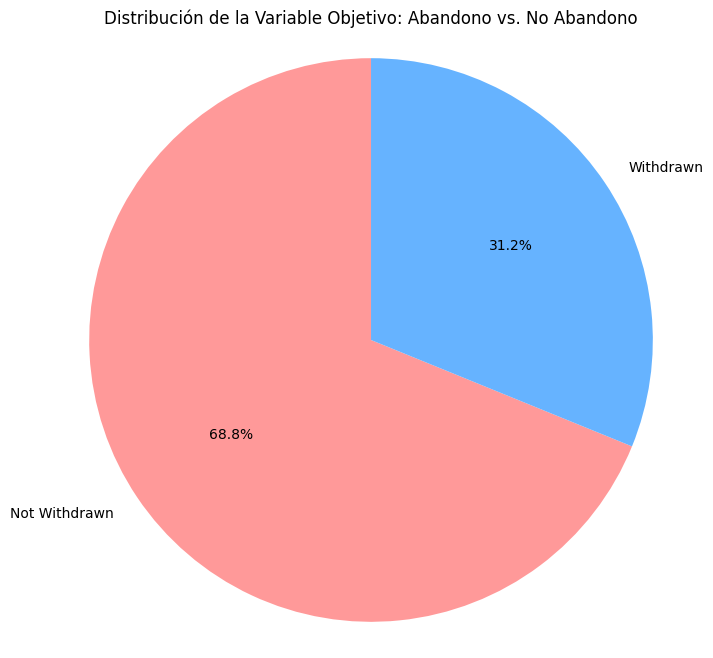

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una nueva variable para agrupar los resultados
student_info['grouped_final_result'] = student_info['final_result'].apply(lambda x: 'Withdrawn' if x == 'Withdrawn' else 'Not Withdrawn')

# Calcular la distribución de la nueva variable
distribution = student_info['grouped_final_result'].value_counts()

# Generar el gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(distribution, labels=distribution.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribución de la Variable Objetivo: Abandono vs. No Abandono')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Opcional: Eliminar la columna temporal si no se necesita más
student_info.drop(columns=['grouped_final_result'], inplace=True)

# **Ingeniería de características**

In [5]:
import pandas as pd
import numpy as np

# --- Ingeniería de Características para Predicción Temprana de Abandono Escolar ---

# --- Base Student Data (pre-merge student_info and student_registration) ---
# Esta es la base común para todas las ventanas temporales
base_student_data = pd.merge(student_info, student_registration,
                             on=['id_student', 'code_module', 'code_presentation'],
                             how='left')

# Determinar la fecha máxima de evaluación para establecer el límite del bucle
max_assessment_date = assessments['date'].max()
print(f"La fecha máxima de evaluación es: {max_assessment_date} días.\n")

# Lista para almacenar los dataframes generados por cada ventana temporal antes de concatenar
all_student_data_list = []

# 2. Definir una ventana temporal para 'predicción temprana' y iterar
current_window_week = 4 # Empezar con 4 semanas

while (current_window_week * 7) <= max_assessment_date:
    window_days = current_window_week * 7
    print(f"\n--- Procesando para la ventana de {current_window_week} semanas ({window_days} días) ---")

    # Crear una copia profunda del DataFrame base para cada iteración
    window_student_data = base_student_data.copy()

    # Añadir la variable objetivo 'dropout'
    window_student_data['dropout'] = window_student_data['final_result'].apply(lambda x: 1 if x == 'Withdrawn' else 0)
    window_student_data = window_student_data.drop('final_result', axis=1)

    # Añadir window_week como característica al DataFrame para esta ventana
    window_student_data['window_week'] = current_window_week

    # --- Características de Evaluaciones Tempranas ---
    student_assessments_details_temp = pd.merge(student_assessments,
                                           assessments[['id_assessment', 'date', 'assessment_type', 'weight', 'code_module', 'code_presentation']],
                                           on='id_assessment',
                                           how='left')

    assessments_data = student_assessments_details_temp[(student_assessments_details_temp['date'] >= (window_days - 28)) & (student_assessments_details_temp['date'] <= window_days)]

    assessments_features = assessments_data.groupby(['id_student', 'code_module', 'code_presentation']).agg(
        num_early_assessments=('id_assessment', 'count'),
        avg_early_score=('score', 'mean'),
        std_early_score=('score', 'std'),
        min_early_score=('score', 'min'),
        max_early_score=('score', 'max'),
        num_failed_early_assessments=('score', lambda x: (x < 40).sum())
    ).reset_index()

    assessments_features['std_early_score'] = assessments_features['std_early_score'].fillna(0)

    window_student_data = pd.merge(window_student_data, assessments_features,
                            on=['id_student', 'code_module', 'code_presentation'],
                            how='left')

    window_student_data['num_early_assessments'] = window_student_data['num_early_assessments'].fillna(0)
    window_student_data['avg_early_score'] = window_student_data['avg_early_score'].fillna(0)
    window_student_data['std_early_score'] = window_student_data['std_early_score'].fillna(0)
    window_student_data['min_early_score'] = window_student_data['min_early_score'].fillna(0)
    window_student_data['max_early_score'] = window_student_data['max_early_score'].fillna(0)
    window_student_data['num_failed_early_assessments'] = window_student_data['num_failed_early_assessments'].fillna(0)
    print("  Características de evaluaciones tempranas agregadas.")

    # --- Características de Actividad VLE Temprana ---
    student_vle_details_temp = pd.merge(student_vle,
                                   vle[['id_site', 'activity_type']],
                                   on='id_site',
                                   how='left')

    vle_data = student_vle_details_temp[(student_vle_details_temp['date'] >= (window_days - 28)) & (student_vle_details_temp['date'] <= window_days)]

    vle_features = vle_data.groupby(['id_student', 'code_module', 'code_presentation']).agg(
        total_early_clicks=('sum_click', 'sum'),
        num_early_vle_interactions=('id_site', 'count'),
        num_unique_early_vle_sites=('id_site', 'nunique'),
        num_early_vle_days=('date', 'nunique')
    ).reset_index()

    vle_features['avg_daily_early_clicks'] = vle_features.apply(lambda row:
        row['total_early_clicks'] / row['num_early_vle_days'] if row['num_early_vle_days'] > 0 else 0,
        axis=1
    )

    vle_activity_type = vle_data.groupby(['id_student', 'code_module', 'code_presentation', 'activity_type']).agg(
        clicks_by_type=('sum_click', 'sum')
    ).unstack(fill_value=0).reset_index()
    vle_activity_type.columns = ['_'.join(col).strip() for col in vle_activity_type.columns.values]
    vle_activity_type.rename(columns={'id_student_': 'id_student', 'code_module_': 'code_module', 'code_presentation_': 'code_presentation'}, inplace=True)

    window_student_data = pd.merge(window_student_data, vle_features,
                            on=['id_student', 'code_module', 'code_presentation'],
                            how='left')
    window_student_data = pd.merge(window_student_data, vle_activity_type,
                            on=['id_student', 'code_module', 'code_presentation'],
                            how='left')

    vle_cols_to_fill = vle_features.columns.drop(['id_student', 'code_module', 'code_presentation']).tolist()
    activity_type_cols_to_fill = [col for col in vle_activity_type.columns if 'clicks_by_type_' in col]

    for col in vle_cols_to_fill + activity_type_cols_to_fill:
        if col in window_student_data.columns:
            window_student_data[col] = window_student_data[col].fillna(0)
    print("  Características de actividad VLE temprana agregadas.")

    # --- Características del Curso (del DataFrame 'courses') ---
    courses_relevant = courses[['code_module', 'code_presentation', 'module_presentation_length']]
    window_student_data = pd.merge(window_student_data, courses_relevant,
                            on=['code_module', 'code_presentation'],
                            how='left')
    print("Longitud de presentación del curso agregada.")

    # Guardar el DataFrame generado para esta ventana en la lista
    all_student_data_list.append(window_student_data)

    # Datos dataframe por ventana
    print(f"  DataFrame generado para la ventana de {current_window_week} semanas guardado.")
    print(f"  Dimensiones del DataFrame generado: {window_student_data.shape}")
    print(f"  Columnas del DataFrame generado: {window_student_data.columns.tolist()[:5]}...")
    pd.set_option('display.max_columns', None)
    print(f" Head: {window_student_data.head(5)}")

    # Incrementar la ventana para la próxima iteración
    current_window_week += 4

# Concatenar todos los DataFrames de la lista en un único DataFrame final
all_student_data_final = pd.concat(all_student_data_list, ignore_index=True)

# Se elimina la característica date_unregistration para evitar data leakage
all_student_data_final.drop(columns=['date_unregistration'], inplace=True)
print("\n--- Resumen del DataFrame final generado ---")
print(f"DataFrame final: Shape {all_student_data_final.shape}, Columnas {all_student_data_final.columns.tolist()[:5]}...")

print("\nValores nulos en el DataFrame final:")
print(all_student_data_final.isnull().sum()[all_student_data_final.isnull().sum() > 0])

La fecha máxima de evaluación es: 261.0 días.


--- Procesando para la ventana de 4 semanas (28 días) ---
  Características de evaluaciones tempranas agregadas.
  Características de actividad VLE temprana agregadas.
Longitud de presentación del curso agregada.
  DataFrame generado para la ventana de 4 semanas guardado.
  Dimensiones del DataFrame generado: (32593, 45)
  Columnas del DataFrame generado: ['code_module', 'code_presentation', 'id_student', 'gender', 'region']...
 Head:   code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_

## 4. Preprocesamiento de datos: Codificación de variables categóricas

In [6]:
# Mapeo explícito para variables ordinales
education_mapping = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}

imd_mapping = {
    '0-10%': 0,
    '10-20%': 1,
    '20-30%': 2,
    '30-40%': 3,
    '40-50%': 4,
    '50-60%': 5,
    '60-70%': 6,
    '70-80%': 7,
    '80-90%': 8,
    '90-100%': 9
}

age_mapping = {
    '0-35': 0,
    '35-55': 1,
    '55<=': 2
}

# Ahora que tenemos un único DataFrame 'all_student_data_final',
# aplicamos el preprocesamiento directamente a este DataFrame.
print("--- Aplicando preprocesamiento al DataFrame final --- ")

df = all_student_data_final.copy() # Trabajar con una copia para evitar SettingWithCopyWarning

# Imputar 'imd_band' con la moda antes del mapeo, si hay NaNs
# Esto se hace aquí porque `imd_band` es una columna categórica que se mapeará.
if df['imd_band'].isnull().any():
    mode_imd_band = df['imd_band'].mode()[0]
    df['imd_band'] = df['imd_band'].fillna(mode_imd_band)
    print(f"  'imd_band' imputado con la moda: {mode_imd_band}.")

# Aplicar mapeos ordinales
df['highest_education_encoded'] = df['highest_education'].map(education_mapping)
df['imd_band_encoded'] = df['imd_band'].map(imd_mapping)
df['age_band_encoded'] = df['age_band'].map(age_mapping)

# One-hot encoding para variables nominales
# Se elimina region ya que se va aplicar en Perú (implementar pipeline para mantener región?)
# df = pd.get_dummies(df, columns=['gender', 'region'], prefix=['gender', 'region'])
df = pd.get_dummies(df, columns=['gender'], prefix=['gender'])

# Eliminar las columnas originales que han sido codificadas/mapeadas
df = df.drop(columns=['highest_education', 'imd_band', 'age_band'])

# Imputación de Valores Nulos restantes (del paso 5 original)
# Imputar 'date_registration' con la mediana
if df['date_registration'].isnull().any():
    median_date_registration = df['date_registration'].median()
    df['date_registration'] = df['date_registration'].fillna(median_date_registration)
    print(f"  'date_registration' imputado con la mediana: {median_date_registration}.")

# Las columnas 'avg_early_score' y 'total_early_clicks' ya deberían estar rellenas con 0 en el paso de ingeniería de características.
# Si aún quedaran NaNs por alguna razón (ej. por merge posterior), se rellenarían aquí.
if 'avg_early_score' in df.columns and df['avg_early_score'].isnull().any():
    df['avg_early_score'] = df['avg_early_score'].fillna(0)
    print(f"  'avg_early_score' imputado con 0.")

if 'total_early_clicks' in df.columns and df['total_early_clicks'].isnull().any():
    df['total_early_clicks'] = df['total_early_clicks'].fillna(0)
    print(f"  'total_early_clicks' imputado con 0.")

# Imputar los valores nulos restantes para las columnas de actividad VLE y imd_band_encoded con 0
# Estos NaNs pueden surgir de merges o de valores no mapeados en imd_band.
for col in ['clicks_by_type_repeatactivity', 'clicks_by_type_folder', 'imd_band_encoded']:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(0)
        print(f"  '{col}' imputado con 0.")

# Finalmente, guardar el DataFrame procesado en una nueva variable
all_student_data_preprocessed = df

print("\n--- Resumen del DataFrame después de codificación e imputación --- ")
print(f"DataFrame: Shape {all_student_data_preprocessed.shape}")
# Mostrar el conteo de NaNs para verificar
null_counts = all_student_data_preprocessed.isnull().sum()
cols_with_nulls = null_counts[null_counts > 0]
if not cols_with_nulls.empty:
    print(f"  Valores nulos restantes:\n{cols_with_nulls}")
else:
    print(f"  No hay valores nulos restantes.")

--- Aplicando preprocesamiento al DataFrame final --- 
  'imd_band' imputado con la moda: 20-30%.
  'date_registration' imputado con la mediana: -57.0.
  'clicks_by_type_repeatactivity' imputado con 0.
  'clicks_by_type_folder' imputado con 0.
  'imd_band_encoded' imputado con 0.

--- Resumen del DataFrame después de codificación e imputación --- 
DataFrame: Shape (293337, 47)
  No hay valores nulos restantes.


In [7]:
print("--- Tipos de datos del DataFrame student_data ---")
all_student_data_preprocessed.info()

--- Tipos de datos del DataFrame student_data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293337 entries, 0 to 293336
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   code_module                    293337 non-null  object 
 1   code_presentation              293337 non-null  object 
 2   id_student                     293337 non-null  int64  
 3   region                         293337 non-null  object 
 4   num_of_prev_attempts           293337 non-null  int64  
 5   studied_credits                293337 non-null  int64  
 6   disability                     293337 non-null  object 
 7   date_registration              293337 non-null  float64
 8   dropout                        293337 non-null  int64  
 9   window_week                    293337 non-null  int64  
 10  num_early_assessments          293337 non-null  float64
 11  avg_early_score                293337 non

## 5. Imputación de Valores Nulos

In [8]:
# Verificar la ausencia de valores nulos en el DataFrame final preprocesado
print("--- Verificación final de valores nulos en el DataFrame preprocesado --- ")

if 'all_student_data_preprocessed' in locals() or 'all_student_data_preprocessed' in globals():
    null_counts_final = all_student_data_preprocessed.isnull().sum()
    cols_with_nulls_final = null_counts_final[null_counts_final > 0]

    if not cols_with_nulls_final.empty:
        print("  Se encontraron valores nulos restantes en el DataFrame final:")
        print(cols_with_nulls_final)
    else:
        print("  No hay valores nulos restantes en el DataFrame 'all_student_data_preprocessed'.")
else:
    print("El DataFrame 'all_student_data_preprocessed' no ha sido creado. Por favor, asegúrese de ejecutar las celdas anteriores.")

--- Verificación final de valores nulos en el DataFrame preprocesado --- 
  No hay valores nulos restantes en el DataFrame 'all_student_data_preprocessed'.


# **6. Entrenamiento preliminar sin tratamiento de datos**

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore') # Ignorar advertencias de convergencia o de otro tipo

print("--- Entrenando y evaluando modelos de clasificación SIN SMOTE ---")

# Recrear X_current y y_current desde all_student_data_preprocessed
X_current_no_smote_prep = all_student_data_preprocessed.drop(columns=['dropout', 'code_module', 'code_presentation', 'id_student', 'window_week', 'region'])
y_current_no_smote_prep = all_student_data_preprocessed['dropout']

# Realizar la división train-test con el mismo random_state que el processed_data_full
X_train_no_smote, X_test_no_smote, y_train_no_smote, y_test_no_smote = train_test_split(
    X_current_no_smote_prep, y_current_no_smote_prep, test_size=0.2, random_state=42, stratify=y_current_no_smote_prep)

# Identificar columnas numéricas, categóricas y booleanas para el ColumnTransformer
# Estas deben ser las mismas que se usarán en el procesamiento con SMOTE para una comparación justa
numerical_cols_no_smote = X_current_no_smote_prep.select_dtypes(include=np.number).columns.tolist()
categorical_cols_no_smote = X_current_no_smote_prep.select_dtypes(include='object').columns.tolist()
boolean_cols_no_smote = X_current_no_smote_prep.select_dtypes(include='bool').columns.tolist()

# Definir el preprocesador aquí para los modelos sin SMOTE
preprocessor_no_smote = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_no_smote),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_no_smote)
    ],
    remainder='passthrough' # Mantiene las columnas booleanas ya creadas
)

# Ajustar el preprocesador solo en los datos de entrenamiento (sin SMOTE)
preprocessor_no_smote.fit(X_train_no_smote)

# Transformar los datos de entrenamiento y prueba usando el preprocesador
X_train_transformed_no_smote = preprocessor_no_smote.transform(X_train_no_smote)
X_test_transformed_no_smote = preprocessor_no_smote.transform(X_test_no_smote)

# Diccionario para almacenar los resultados de los modelos sin SMOTE
model_results_no_smote = {}

# Definir los modelos a entrenar
models_no_smote = {
    'Logistic Regression (No SMOTE)': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Random Forest (No SMOTE)': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting (No SMOTE)': GradientBoostingClassifier(random_state=42)
}

# Loop a través de los modelos y entrenar/evaluar
for model_name, model in models_no_smote.items():
    print(f"  Entrenando {model_name}...")
    model.fit(X_train_transformed_no_smote, y_train_no_smote)
    y_pred = model.predict(X_test_transformed_no_smote)
    y_proba = model.predict_proba(X_test_transformed_no_smote)[:, 1]

    accuracy = accuracy_score(y_test_no_smote, y_pred)
    precision = precision_score(y_test_no_smote, y_pred)
    recall = recall_score(y_test_no_smote, y_pred)
    f1 = f1_score(y_test_no_smote, y_pred)
    roc_auc = roc_auc_score(y_test_no_smote, y_proba)

    model_results_no_smote[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc_score': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"    {model_name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, ROC AUC: {roc_auc:.4f}")

print("\n--- Entrenamiento y evaluación de modelos SIN SMOTE completado. ---")

--- Entrenando y evaluando modelos de clasificación SIN SMOTE ---
  Entrenando Logistic Regression (No SMOTE)...
    Logistic Regression (No SMOTE) - Accuracy: 0.7716, Precision: 0.5945, Recall: 0.8395, F1-Score: 0.6961, ROC AUC: 0.8524
  Entrenando Random Forest (No SMOTE)...
    Random Forest (No SMOTE) - Accuracy: 0.9141, Precision: 0.9423, Recall: 0.7716, F1-Score: 0.8485, ROC AUC: 0.9457
  Entrenando Gradient Boosting (No SMOTE)...
    Gradient Boosting (No SMOTE) - Accuracy: 0.8263, Precision: 0.7137, Recall: 0.7391, F1-Score: 0.7262, ROC AUC: 0.8738

--- Entrenamiento y evaluación de modelos SIN SMOTE completado. ---


## 6.1. Métricas de rendimiento sin SMOTE

In [11]:
print("--- Resumen de Resultados de Modelos SIN SMOTE ---")

# Crear un DataFrame para almacenar todos los resultados y facilitar la visualización
all_results_no_smote_df = pd.DataFrame()

for model_name, metrics in model_results_no_smote.items():
    result_row = {
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1_score'],
        'ROC AUC': metrics['roc_auc_score']
    }
    all_results_no_smote_df = pd.concat([all_results_no_smote_df, pd.DataFrame([result_row])], ignore_index=True)
    print(f"  {model_name}:")
    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    Precision: {metrics['precision']:.4f}")
    print(f"    Recall: {metrics['recall']:.4f}")
    print(f"    F1-Score: {metrics['f1_score']:.4f}")
    print(f"    ROC AUC: {metrics['roc_auc_score']:.4f}")

print("\n--- Tabla Resumen Completa (SIN SMOTE) ---")
# Mostrar el DataFrame completo ordenado por ROC AUC
print(all_results_no_smote_df.sort_values(by=['ROC AUC'], ascending=False).to_markdown(index=False))

print("\nEstos resultados pueden compararse con los modelos entrenados después de aplicar SMOTE.")

--- Resumen de Resultados de Modelos SIN SMOTE ---
  Logistic Regression (No SMOTE):
    Accuracy: 0.7716
    Precision: 0.5945
    Recall: 0.8395
    F1-Score: 0.6961
    ROC AUC: 0.8524
  Random Forest (No SMOTE):
    Accuracy: 0.9141
    Precision: 0.9423
    Recall: 0.7716
    F1-Score: 0.8485
    ROC AUC: 0.9457
  Gradient Boosting (No SMOTE):
    Accuracy: 0.8263
    Precision: 0.7137
    Recall: 0.7391
    F1-Score: 0.7262
    ROC AUC: 0.8738

--- Tabla Resumen Completa (SIN SMOTE) ---
| Model                          |   Accuracy |   Precision |   Recall |   F1-Score |   ROC AUC |
|:-------------------------------|-----------:|------------:|---------:|-----------:|----------:|
| Random Forest (No SMOTE)       |   0.914127 |    0.942348 | 0.771621 |   0.848481 |  0.945722 |
| Gradient Boosting (No SMOTE)   |   0.826311 |    0.713697 | 0.739073 |   0.726164 |  0.87381  |
| Logistic Regression (No SMOTE) |   0.771579 |    0.594522 | 0.839505 |   0.696088 |  0.852436 |

Estos resul

## 7. Balanceo de Clases con SMOTE

La variable objetivo `dropout` está desbalanceada (aproximadamente 31% 'Withdrawn' y 69% 'Not Withdrawn'). Para abordar este desbalance, aplicaremos la técnica **SMOTE (Synthetic Minority Over-sampling Technique)**. Esto ayudará a que el modelo no se incline a predecir la clase mayoritaria.

Antes de aplicar SMOTE, necesitamos:
1.  Separar las características (`X`) de la variable objetivo (`y`).
2.  Identificar las columnas numéricas y categóricas para el preprocesamiento, ya que SMOTE opera en datos numéricos. Esto incluye la codificación one-hot de las variables 'object' y la escalada de las variables numéricas.

In [12]:
print("--- Aplicando separación, preprocesamiento y SMOTE al DataFrame ---")

# Usar el DataFrame completo 'all_student_data_preprocessed'
current_df = all_student_data_preprocessed.copy()

# 1. Separar características (X) y variable objetivo (y)
# 'code_module', 'code_presentation', 'id_student' son identificadores y no deben usarse como features.
# 'date_unregistration' se elimina para evaluar su impacto.
# 'window_week' también se elimina ya que no se fracciona por ventana.
# Se elimina ´region´, se debe determinar si se implementa un pipeline para el tratamiendo de los datos
X_current = current_df.drop(columns=['dropout', 'code_module', 'code_presentation', 'id_student', 'window_week', 'region'])
y_current = current_df['dropout']

# Identificar columnas numéricas, categóricas y booleanas para el ColumnTransformer
# Las columnas booleanas son el resultado de OneHotEncoder previos y ya están en formato numérico (0/1)
numerical_cols = X_current.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_current.select_dtypes(include='object').columns.tolist()
boolean_cols = X_current.select_dtypes(include='bool').columns.tolist()

# Preprocesamiento: Escalar características numéricas y One-Hot Encode para categóricas
# 'remainder='passthrough'' para mantener las columnas booleanas que ya están en el formato correcto
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols) # Maneja 'disability' y cualquier otro 'object' si lo hubiera
    ],
    remainder='passthrough' # Mantiene las columnas booleanas ya creadas
)

# Primero, dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_current, y_current, test_size=0.2, random_state=42, stratify=y_current)

print(f"  Dimensiones de X_train antes de SMOTE: {X_train.shape}")
print(f"  Distribución de clases en y_train antes de SMOTE:\n{y_train.value_counts(normalize=True)}")

# Crear un pipeline con preprocesamiento y SMOTE
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42))
])

# Aplicar el pipeline solo a los datos de entrenamiento
X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train, y_train)

print(f"  Dimensiones de X_train_resampled después de SMOTE: {X_train_resampled.shape}")
print(f"  Distribución de clases en y_train_resampled después de SMOTE:\n{y_train_resampled.value_counts(normalize=True)}")
print(f"  Balanceo de clases completado usando SMOTE.")

# Almacenar los resultados procesados
processed_data_full = {
    'X_train_resampled': X_train_resampled,
    'y_train_resampled': y_train_resampled,
    'X_test': X_test,
    'y_test': y_test,
    'preprocessor': preprocessor
}

print("\n--- Resumen de datos procesados ---")
print(f"  X_train_resampled shape: {processed_data_full['X_train_resampled'].shape}")
print(f"  y_train_resampled distribution:\n{processed_data_full['y_train_resampled'].value_counts(normalize=True)}")
print(f"  X_test shape: {processed_data_full['X_test'].shape}")
print(f"  y_test distribution:\n{processed_data_full['y_test'].value_counts(normalize=True)}")

--- Aplicando separación, preprocesamiento y SMOTE al DataFrame ---
  Dimensiones de X_train antes de SMOTE: (234669, 41)
  Distribución de clases en y_train antes de SMOTE:
dropout
0    0.688399
1    0.311601
Name: proportion, dtype: float64
  Dimensiones de X_train_resampled después de SMOTE: (323092, 42)
  Distribución de clases en y_train_resampled después de SMOTE:
dropout
0    0.5
1    0.5
Name: proportion, dtype: float64
  Balanceo de clases completado usando SMOTE.

--- Resumen de datos procesados ---
  X_train_resampled shape: (323092, 42)
  y_train_resampled distribution:
dropout
0    0.5
1    0.5
Name: proportion, dtype: float64
  X_test shape: (58668, 41)
  y_test distribution:
dropout
0    0.688399
1    0.311601
Name: proportion, dtype: float64


### 7.1 Visualización del Balanceo de Clases

--- Visualizando el balanceo de clases antes y después de SMOTE para el DataFrame completo ---


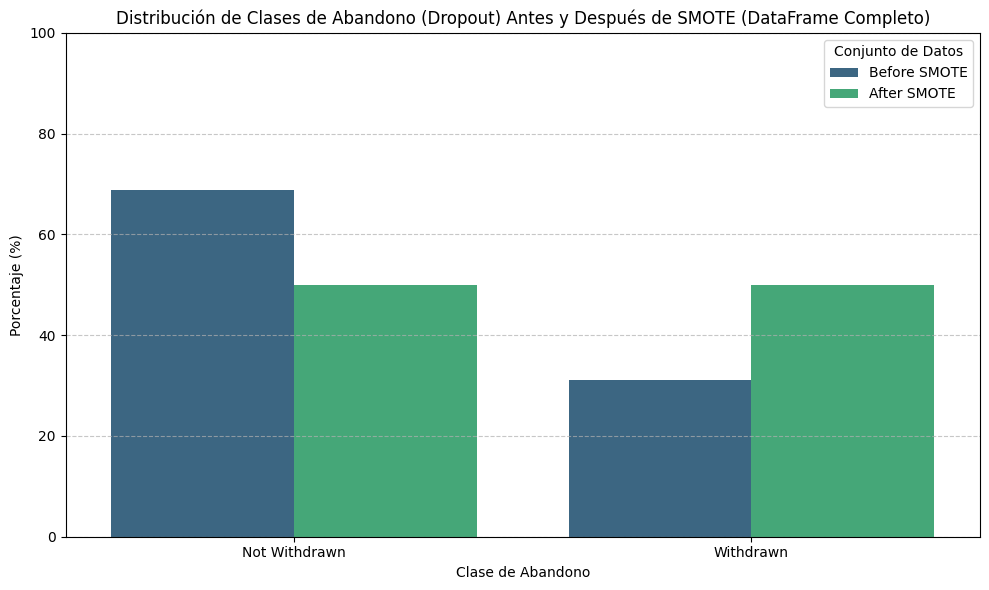

--- Visualización de balanceo de clases completada para el DataFrame completo. ---


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Visualizando el balanceo de clases antes y después de SMOTE para el DataFrame completo ---")

# Obtener las distribuciones de clases antes (usando y_test como proxy) y después de SMOTE del DataFrame completo
# `processed_data_full` contiene los datos procesados del DataFrame completo
original_distribution = processed_data_full['y_test'].value_counts(normalize=True).mul(100)
resampled_distribution = processed_data_full['y_train_resampled'].value_counts(normalize=True).mul(100)

# Crear un DataFrame para facilitar la visualización
df_plot = pd.DataFrame({
    'Before SMOTE': original_distribution,
    'After SMOTE': resampled_distribution
}).reset_index()

# Corregir el nombre de la columna para la clase de abandono
df_plot = df_plot.rename(columns={'dropout': 'Dropout Class'})

# Mapear 0 y 1 a etiquetas más descriptivas
df_plot['Dropout Class'] = df_plot['Dropout Class'].map({0: 'Not Withdrawn', 1: 'Withdrawn'})

# Reorganizar el DataFrame para seaborn.barplot
df_plot_melted = df_plot.melt(id_vars='Dropout Class', var_name='Dataset', value_name='Percentage')

plt.figure(figsize=(10, 6))
sns.barplot(x='Dropout Class', y='Percentage', hue='Dataset', data=df_plot_melted, palette='viridis')
plt.title('Distribución de Clases de Abandono (Dropout) Antes y Después de SMOTE (DataFrame Completo)')
plt.xlabel('Clase de Abandono')
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 100)
plt.legend(title='Conjunto de Datos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- Visualización de balanceo de clases completada para el DataFrame completo. ---")

# **8. Entrenamiento y evaluación de modelos (Logistic Regression, RandomForest y Gradient Boosting)**

Procesamiento de datos

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore') # Ignorar advertencias de convergencia o de otro tipo

# Diccionario para almacenar los resultados de los modelos
model_results_full = {}

print("--- Entrenando y evaluando modelos de clasificación para el DataFrame completo ---")

# Obtener los datos procesados del DataFrame completo
X_train_resampled = processed_data_full['X_train_resampled']
y_train_resampled = processed_data_full['y_train_resampled']
X_test_original = processed_data_full['X_test']
y_test = processed_data_full['y_test']
preprocessor = processed_data_full['preprocessor']

# Transformar X_test usando el mismo preprocesador ajustado en X_train
X_test_transformed = preprocessor.transform(X_test_original)

--- Entrenando y evaluando modelos de clasificación para el DataFrame completo ---


Configuración y entrenamiento de modelos

In [15]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Loop a través de los modelos y entrenar/evaluar
for model_name, model in models.items():
    print(f"  Entrenando {model_name}...")
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_transformed)

    # Para modelos que no tienen predict_proba (como LinearSVC sin probability=True), se podría usar decision_function
    # Sin embargo, con SVC(kernel='linear', probability=True), predict_proba estará disponible.
    y_proba = model.predict_proba(X_test_transformed)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    model_results_full[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc_score': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"    {model_name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, ROC AUC: {roc_auc:.4f}")

print("\n--- Entrenamiento y evaluación de modelos completado para el DataFrame completo. ---")

  Entrenando Logistic Regression...
    Logistic Regression - Accuracy: 0.7723, Precision: 0.5957, Recall: 0.8381, F1-Score: 0.6964, ROC AUC: 0.8526
  Entrenando Random Forest...
    Random Forest - Accuracy: 0.9142, Precision: 0.9377, Recall: 0.7761, F1-Score: 0.8493, ROC AUC: 0.9460
  Entrenando Gradient Boosting...
    Gradient Boosting - Accuracy: 0.8200, Precision: 0.6898, Recall: 0.7676, F1-Score: 0.7266, ROC AUC: 0.8720

--- Entrenamiento y evaluación de modelos completado para el DataFrame completo. ---


# **8.1 Métricas de rendimiento**

In [16]:
print("--- Resumen de Resultados de Modelos para el DataFrame completo ---")

# Crear un DataFrame para almacenar todos los resultados y facilitar la visualización
all_results_df = pd.DataFrame()

# Como model_results_full es un diccionario con resultados de un solo conjunto de datos (no por ventana temporal),
# ajustamos el bucle para iterar directamente sobre él.
for model_name, metrics in model_results_full.items():
    result_row = {
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1_score'],
        'ROC AUC': metrics['roc_auc_score']
    }
    all_results_df = pd.concat([all_results_df, pd.DataFrame([result_row])], ignore_index=True)
    print(f"  {model_name}:")
    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    Precision: {metrics['precision']:.4f}")
    print(f"    Recall: {metrics['recall']:.4f}")
    print(f"    F1-Score: {metrics['f1_score']:.4f}")
    print(f"    ROC AUC: {metrics['roc_auc_score']:.4f}")

print("\n--- Tabla Resumen Completa (DataFrame completo) ---")
# Mostrar el DataFrame completo ordenado por ROC AUC
print(all_results_df.sort_values(by=['ROC AUC'], ascending=False).to_markdown(index=False))

print("\nDe los resultados, podemos analizar el rendimiento de cada modelo en el DataFrame completo.")

--- Resumen de Resultados de Modelos para el DataFrame completo ---
  Logistic Regression:
    Accuracy: 0.7723
    Precision: 0.5957
    Recall: 0.8381
    F1-Score: 0.6964
    ROC AUC: 0.8526
  Random Forest:
    Accuracy: 0.9142
    Precision: 0.9377
    Recall: 0.7761
    F1-Score: 0.8493
    ROC AUC: 0.9460
  Gradient Boosting:
    Accuracy: 0.8200
    Precision: 0.6898
    Recall: 0.7676
    F1-Score: 0.7266
    ROC AUC: 0.8720

--- Tabla Resumen Completa (DataFrame completo) ---
| Model               |   Accuracy |   Precision |   Recall |   F1-Score |   ROC AUC |
|:--------------------|-----------:|------------:|---------:|-----------:|----------:|
| Random Forest       |   0.914161 |    0.937735 | 0.776052 |   0.849267 |  0.945999 |
| Gradient Boosting   |   0.820021 |    0.689786 | 0.767628 |   0.726628 |  0.871973 |
| Logistic Regression |   0.772329 |    0.595723 | 0.838138 |   0.696439 |  0.85262  |

De los resultados, podemos analizar el rendimiento de cada modelo en el D

**8.2 Comparación métricas entre modelos con y sin SMOTE**

Para comparar los resultados, primero mostraremos las métricas de los modelos entrenados con SMOTE (DataFrame completo) y luego las de los modelos entrenados sin SMOTE.

In [17]:
print("--- Métricas de rendimiento de modelos CON SMOTE (DataFrame completo) ---")
print(all_results_df.sort_values(by=['ROC AUC'], ascending=False).to_markdown(index=False))

print("\n--- Métricas de rendimiento de modelos SIN SMOTE ---")
print(all_results_no_smote_df.sort_values(by=['ROC AUC'], ascending=False).to_markdown(index=False))

--- Métricas de rendimiento de modelos CON SMOTE (DataFrame completo) ---
| Model               |   Accuracy |   Precision |   Recall |   F1-Score |   ROC AUC |
|:--------------------|-----------:|------------:|---------:|-----------:|----------:|
| Random Forest       |   0.914161 |    0.937735 | 0.776052 |   0.849267 |  0.945999 |
| Gradient Boosting   |   0.820021 |    0.689786 | 0.767628 |   0.726628 |  0.871973 |
| Logistic Regression |   0.772329 |    0.595723 | 0.838138 |   0.696439 |  0.85262  |

--- Métricas de rendimiento de modelos SIN SMOTE ---
| Model                          |   Accuracy |   Precision |   Recall |   F1-Score |   ROC AUC |
|:-------------------------------|-----------:|------------:|---------:|-----------:|----------:|
| Random Forest (No SMOTE)       |   0.914127 |    0.942348 | 0.771621 |   0.848481 |  0.945722 |
| Gradient Boosting (No SMOTE)   |   0.826311 |    0.713697 | 0.739073 |   0.726164 |  0.87381  |
| Logistic Regression (No SMOTE) |   0.771579

Ahora, combinemos ambos DataFrames para una comparación más sencilla y directa.

In [18]:
print("--- Comparación de Métricas de Modelos (CON vs. SIN SMOTE) ---")

# Añadir una columna para indicar si SMOTE fue usado
all_results_df['SMOTE_Applied'] = 'Yes'
all_results_no_smote_df['SMOTE_Applied'] = 'No'

# Unir ambos DataFrames
comparison_df = pd.concat([all_results_df, all_results_no_smote_df], ignore_index=True)

# Reordenar columnas para mejor visualización y ordenar por métrica y tipo de modelo
comparison_df = comparison_df[['Model', 'SMOTE_Applied', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']]
comparison_df['Model_Base'] = comparison_df['Model'].apply(lambda x: x.replace(' (No SMOTE)', ''))
comparison_df = comparison_df.sort_values(by=['Model_Base', 'ROC AUC'], ascending=[True, False]).drop(columns=['Model_Base'])

print(comparison_df.to_markdown(index=False))

print("\nEsta tabla muestra claramente el impacto de SMOTE en las métricas de cada modelo.")

--- Comparación de Métricas de Modelos (CON vs. SIN SMOTE) ---
| Model                          | SMOTE_Applied   |   Accuracy |   Precision |   Recall |   F1-Score |   ROC AUC |
|:-------------------------------|:----------------|-----------:|------------:|---------:|-----------:|----------:|
| Gradient Boosting (No SMOTE)   | No              |   0.826311 |    0.713697 | 0.739073 |   0.726164 |  0.87381  |
| Gradient Boosting              | Yes             |   0.820021 |    0.689786 | 0.767628 |   0.726628 |  0.871973 |
| Logistic Regression            | Yes             |   0.772329 |    0.595723 | 0.838138 |   0.696439 |  0.85262  |
| Logistic Regression (No SMOTE) | No              |   0.771579 |    0.594522 | 0.839505 |   0.696088 |  0.852436 |
| Random Forest                  | Yes             |   0.914161 |    0.937735 | 0.776052 |   0.849267 |  0.945999 |
| Random Forest (No SMOTE)       | No              |   0.914127 |    0.942348 | 0.771621 |   0.848481 |  0.945722 |

Esta tab

### 7.1. Visualización del ROC AUC

--- Generando gráfica comparativa de ROC AUC ---


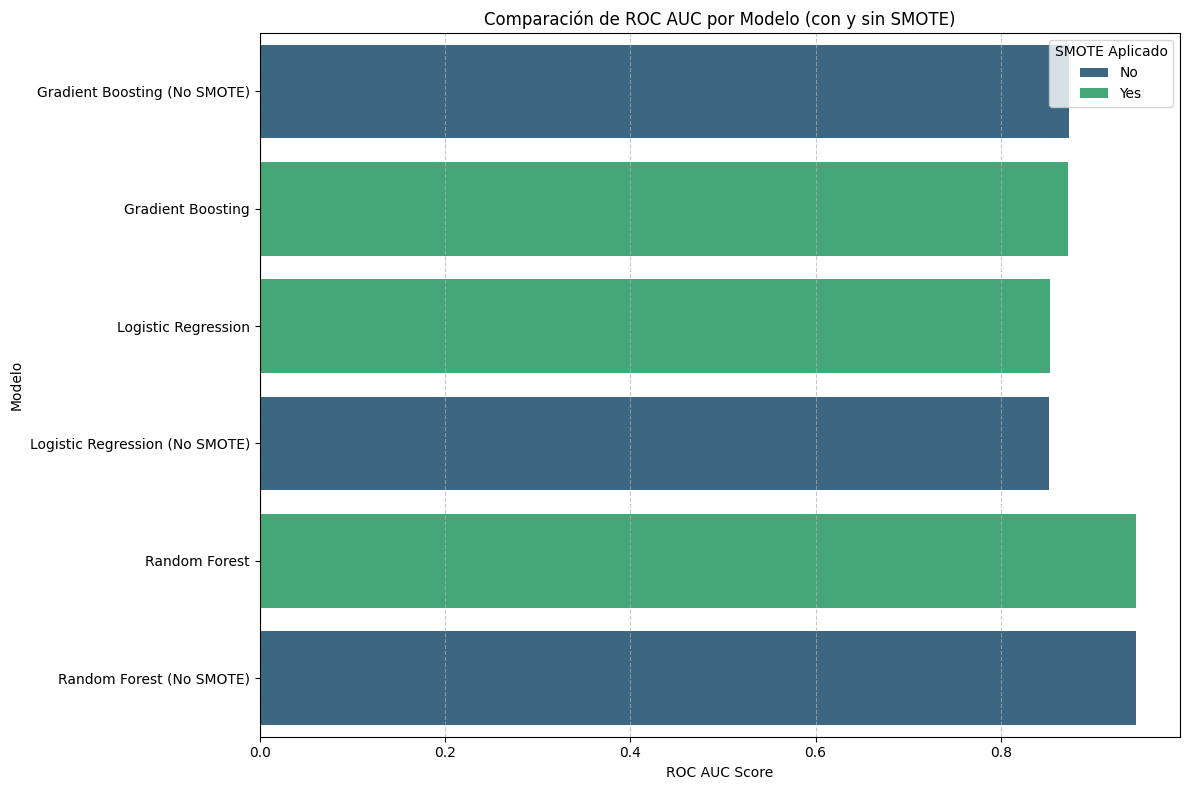

--- Gráfica de comparación de ROC AUC generada. ---


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Generando gráfica comparativa de ROC AUC ---")

# Recrear la columna 'Model_Base' para el ordenamiento dentro de esta celda
comparison_df['Model_Base'] = comparison_df['Model'].apply(lambda x: x.replace(' (No SMOTE)', ''))

plt.figure(figsize=(12, 8))
sns.barplot(x='ROC AUC', y='Model', hue='SMOTE_Applied', data=comparison_df.sort_values(by=['Model_Base', 'ROC AUC'], ascending=[True, False]), palette='viridis')
plt.title('Comparación de ROC AUC por Modelo (con y sin SMOTE)')
plt.xlabel('ROC AUC Score')
plt.ylabel('Modelo')
plt.legend(title='SMOTE Aplicado')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Eliminar la columna temporal 'Model_Base' si no se necesita más
comparison_df.drop(columns=['Model_Base'], inplace=True)

print("--- Gráfica de comparación de ROC AUC generada. ---")

### 7.2. Selección del Mejor Modelo y Análisis de Importancia de Características

In [21]:
# Identify the model with the best average ROC AUC across all windows
average_roc_auc = all_results_df.groupby('Model')['ROC AUC'].mean().sort_values(ascending=False)
best_model_name = average_roc_auc.index[0]

print(f"El mejor modelo en promedio (basado en ROC AUC) es: {best_model_name}")



El mejor modelo en promedio (basado en ROC AUC) es: Random Forest


# **8. Ajustes de hiperparámetros**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

print("--- Ajuste de hiperparámetros para Random Forest (GridSearchCV y RandomizedSearchCV) ---")

# Obtener los datos de entrenamiento resampleados
X_train_resampled = processed_data_full['X_train_resampled']
y_train_resampled = processed_data_full['y_train_resampled']

# Inicializar el modelo Random Forest con el class_weight
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# --- 1. Ajuste con GridSearchCV ---
print("\nIniciando ajuste con GridSearchCV...")
param_grid_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_grid,
    scoring='roc_auc',
    cv=3, # Usar 3-fold cross-validation
    n_jobs=-1, # Usar todos los núcleos disponibles
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)

print("GridSearchCV completado.")
print(f"Mejores parámetros con GridSearchCV: {grid_search.best_params_}")
print(f"Mejor ROC AUC con GridSearchCV: {grid_search.best_score_:.4f}")

# --- 2. Ajuste con RandomizedSearchCV ---
print("\nIniciando ajuste con RandomizedSearchCV...")
param_grid_random = {
    'n_estimators': [100, 200, 300, 400],
    'max_features': ['sqrt', None],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_random,
    n_iter=10, # Número de combinaciones a probar (ajustar según recursos)
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_resampled, y_train_resampled)

print("RandomizedSearchCV completado.")
print(f"Mejores parámetros con RandomizedSearchCV: {random_search.best_params_}")
print(f"Mejor ROC AUC con RandomizedSearchCV: {random_search.best_score_:.4f}")

print("\n--- Ajustes de hiperparámetros finalizados. ---")

--- Ajuste de hiperparámetros para Random Forest (GridSearchCV y RandomizedSearchCV) ---

Iniciando ajuste con GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
GridSearchCV completado.
Mejores parámetros con GridSearchCV: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor ROC AUC con GridSearchCV: 0.9527

Iniciando ajuste con RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


# **8.1 Reconfiguración del mejor modelo**

In [ ]:
print("--- Reconfigurando y evaluando el mejor modelo Random Forest ---\n")

# Obtener los mejores parámetros de RandomizedSearchCV
# best_random_params = random_search.best_params_

# Se obtienen los datos en tiempo de ejecución
# Crear una nueva instancia de RandomForestClassifier con los mejores parámetros
#best_rf_model = RandomForestClassifier(
#    random_state=42,
#    class_weight='balanced',
#    n_estimators=best_random_params['n_estimators'],
#    min_samples_split=best_random_params['min_samples_split'],
#    min_samples_leaf=best_random_params['min_samples_leaf'],
#    max_features=best_random_params['max_features'],
#    max_depth=best_random_params['max_depth'],
#    bootstrap=best_random_params['bootstrap']
#)

# Hiperparámetros obtenidos
# Crear una nueva instancia de RandomForestClassifier con los mejores parámetros
best_rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_estimators=400,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=None,
    bootstrap=True
)
print("  Entrenando el modelo Random Forest reconfigurado...")
best_rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_tuned = best_rf_model.predict(X_test_transformed)
y_proba_tuned = best_rf_model.predict_proba(X_test_transformed)[:, 1]

# Evaluar el modelo reconfigurado
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)

print(f"  Modelo Random Forest Reconfigurado - Accuracy: {accuracy_tuned:.4f}, Precision: {precision_tuned:.4f}, Recall: {recall_tuned:.4f}, F1-Score: {f1_tuned:.4f}, ROC AUC: {roc_auc_tuned:.4f}")

# Actualizar los resultados en model_results_full (o crear una nueva entrada)
model_results_full['Random Forest Tuned'] = {
    'model': best_rf_model,
    'accuracy': accuracy_tuned,
    'precision': precision_tuned,
    'recall': recall_tuned,
    'f1_score': f1_tuned,
    'roc_auc_score': roc_auc_tuned,
    'y_pred': y_pred_tuned,
    'y_proba': y_proba_tuned
}

print("\n--- Reconfiguración y evaluación del modelo Random Forest completada. ---")

--- Reconfigurando y evaluando el mejor modelo Random Forest ---

  Entrenando el modelo Random Forest reconfigurado...
  Modelo Random Forest Reconfigurado - Accuracy: 0.9154, Precision: 0.9340, Recall: 0.7839, F1-Score: 0.8524, ROC AUC: 0.9453

--- Reconfiguración y evaluación del modelo Random Forest completada. ---


Métricas del modelo Random Forest reconfigurado

In [ ]:
print("--- Métricas del modelo Random Forest Reconfigurado ---")

# Obtener las métricas del modelo Random Forest Tuned
metrics_tuned = model_results_full['Random Forest Tuned']

print(f"  Accuracy: {metrics_tuned['accuracy']:.4f}")
print(f"  Precision: {metrics_tuned['precision']:.4f}")
print(f"  Recall: {metrics_tuned['recall']:.4f}")
print(f"  F1-Score: {metrics_tuned['f1_score']:.4f}")
print(f"  ROC AUC: {metrics_tuned['roc_auc_score']:.4f}")

print("\n--- Visualización de métricas completada. ---")

--- Métricas del modelo Random Forest Reconfigurado ---
  Accuracy: 0.9154
  Precision: 0.9340
  Recall: 0.7839
  F1-Score: 0.8524
  ROC AUC: 0.9453

--- Visualización de métricas completada. ---


Reporte de clasificación del modelo RF Tuned

In [ ]:
from sklearn.metrics import classification_report

print("--- Reporte de Clasificación para el modelo Random Forest Ajustado ---\n")

# Obtener las predicciones del modelo Random Forest ajustado
y_pred_tuned = model_results_full['Random Forest Tuned']['y_pred']
y_test = processed_data_full['y_test'] # Asegurarse de usar el y_test original

# Generar y mostrar el reporte de clasificación
report = classification_report(y_test, y_pred_tuned, target_names=['No Abandono', 'Abandono'])
print(report)

print("\n--- Reporte de clasificación completado. ---")

--- Reporte de Clasificación para el modelo Random Forest Ajustado ---

              precision    recall  f1-score   support

 No Abandono       0.91      0.97      0.94     40387
    Abandono       0.93      0.78      0.85     18281

    accuracy                           0.92     58668
   macro avg       0.92      0.88      0.90     58668
weighted avg       0.92      0.92      0.91     58668


--- Reporte de clasificación completado. ---


**Matriz de confusión modelo Random Forest Reconfigurado**

--- Visualizando la matriz de confusión para el modelo Random Forest Ajustado ---


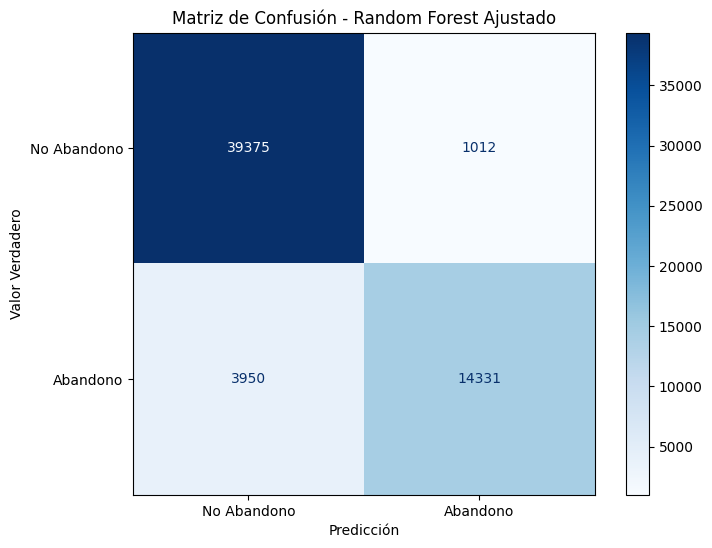

--- Visualización de la matriz de confusión completada. ---


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- Visualizando la matriz de confusión para el modelo Random Forest Ajustado ---")

# Obtener las predicciones y las etiquetas verdaderas del modelo ajustado
y_pred_tuned = model_results_full['Random Forest Tuned']['y_pred']
y_test = processed_data_full['y_test'] # Asegurarse de usar el y_test original

# Crear la matriz de confusión y visualizarla
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, ax=ax, cmap='Blues', display_labels=['No Abandono', 'Abandono'])
plt.title('Matriz de Confusión - Random Forest Ajustado')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.grid(False)
plt.show()

print("--- Visualización de la matriz de confusión completada. ---")

# **Visualización curva ROC-AUC**

--- Visualizando la curva ROC-AUC del modelo Random Forest ajustado ---


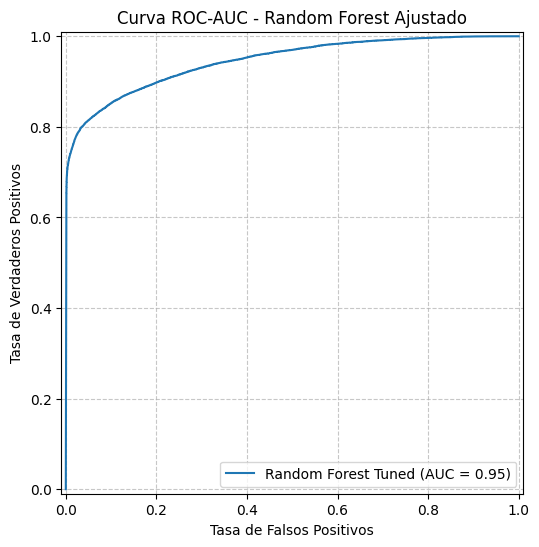

--- Visualización de la curva ROC-AUC completada. ---


In [ ]:
print("--- Visualizando la curva ROC-AUC del modelo Random Forest ajustado ---")

# Obtener el modelo ajustado y sus probabilidades del diccionario de resultados
best_rf_model_tuned = model_results_full['Random Forest Tuned']['model']
y_proba_tuned = model_results_full['Random Forest Tuned']['y_proba']
y_test = processed_data_full['y_test'] # Asegurarse de usar el y_test original

plt.figure(figsize=(8, 6))
ax = plt.gca()

RocCurveDisplay.from_estimator(best_rf_model_tuned, X_test_transformed, y_test, ax=ax, name='Random Forest Tuned')
plt.title('Curva ROC-AUC - Random Forest Ajustado')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

print("--- Visualización de la curva ROC-AUC completada. ---")

# **Importancia de características**

--- Visualizando la importancia de las características del modelo Random Forest ajustado ---


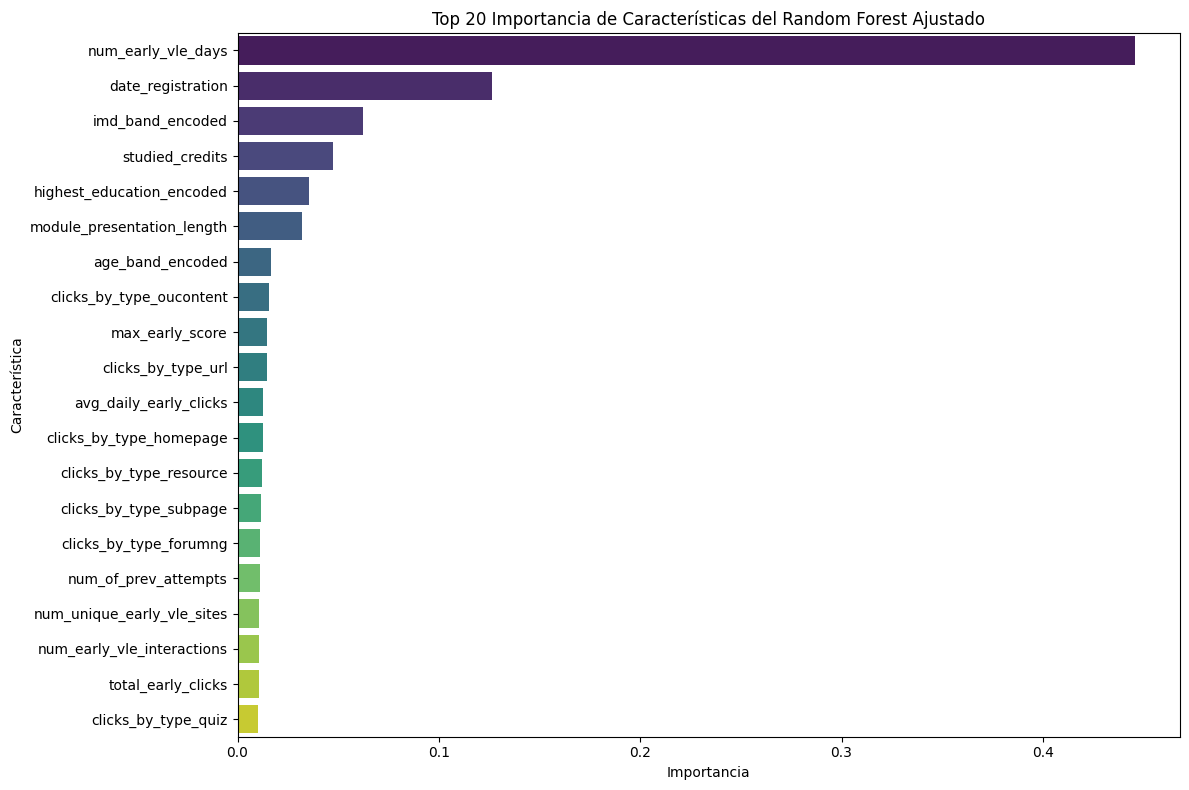

--- Visualización de la importancia de las características completada. ---


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Visualizando la importancia de las características del modelo Random Forest ajustado ---")

# Obtener el modelo Random Forest ajustado
# best_rf_model_tuned = model_results_full['Random Forest Tuned']['model']
best_rf_model_tuned = best_rf_model
# Obtener el objeto ColumnTransformer usado para el preprocesamiento
preprocessor = processed_data_full['preprocessor']

# Obtener los nombres de las características después del preprocesamiento
# ColumnTransformer.get_feature_names_out() proporciona los nombres correctos
transformed_feature_names = preprocessor.get_feature_names_out()

# Limpiar los nombres de las características para una mejor visualización
cleaned_feature_names = []
for name in transformed_feature_names:
    # Eliminar prefijos del ColumnTransformer (e.g., 'num__', 'cat__', 'remainder__')
    if name.startswith('num__'):
        cleaned_feature_names.append(name.replace('num__', ''))
    elif name.startswith('cat__'):
        cleaned_feature_names.append(name.replace('cat__', ''))
    elif name.startswith('remainder__'):
        cleaned_feature_names.append(name.replace('remainder__', ''))
    else:
        cleaned_feature_names.append(name)

# Crear un DataFrame con la importancia de las características
feature_importance_df = pd.DataFrame({
    'Feature': cleaned_feature_names,
    'Importance': best_rf_model_tuned.feature_importances_
})

# Ordenar por importancia y seleccionar las top N características
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualizar las top 20 características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Importancia de Características del Random Forest Ajustado')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

print("--- Visualización de la importancia de las características completada. ---")

# **Explicabilidad con SHAP**

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") # Suprimir todas las advertencias en esta celda

print("--- Generando explicabilidad con SHAP para el modelo Random Forest ajustado ---")

try:
    # 1. Obtener el modelo y los datos preprocesados
    best_rf_model_tuned = best_rf_model
    preprocessor = processed_data_full['preprocessor']
    X_train_resampled_np = processed_data_full['X_train_resampled'] # Es un numpy array
    X_test_original = processed_data_full['X_test']

    # Transformar X_test usando el preprocesador (devuelve un numpy array)
    X_test_transformed_np = preprocessor.transform(X_test_original)

    # Obtener los nombres de las características después del preprocesamiento
    transformed_feature_names = preprocessor.get_feature_names_out()
    cleaned_feature_names = []
    for name in transformed_feature_names:
        if name.startswith('num__'):
            cleaned_feature_names.append(name.replace('num__', ''))
        elif name.startswith('cat__'):
            cleaned_feature_names.append(name.replace('cat__', ''))
        elif name.startswith('remainder__'):
            cleaned_feature_names.append(name.replace('remainder__', ''))
        else:
            cleaned_feature_names.append(name)

    # Convertir los arrays numpy a DataFrames con nombres de columnas para SHAP
    X_train_resampled_df = pd.DataFrame(X_train_resampled_np, columns=cleaned_feature_names)
    X_test_transformed_df = pd.DataFrame(X_test_transformed_np, columns=cleaned_feature_names)

    # Tomar una muestra de los datos de entrenamiento para el fondo del explainer
    # Esto es importante si el conjunto de entrenamiento es muy grande para TreeExplainer.
    n_background_sample = min(100, X_train_resampled_df.shape[0])
    background_sample = X_train_resampled_df.sample(n=n_background_sample, random_state=42)

    # Tomar una muestra de los datos de prueba para calcular los valores SHAP
    # Reducimos la muestra para mitigar problemas de memoria.
    n_test_sample = min(10, X_test_transformed_df.shape[0]) # Reducido a 10
    X_test_sample = X_test_transformed_df.sample(n=n_test_sample, random_state=42)

    # 2. Inicializar el Explainer de SHAP
    # Para modelos de tipo `sklearn.ensemble.RandomForestClassifier`, `shap.TreeExplainer` es el más eficiente.
    explainer = shap.TreeExplainer(best_rf_model_tuned, background_sample)

    # 3. Calcular los valores SHAP
    # shap_values será una lista de matrices, una por cada clase.
    # shap_values[0] para la clase 'No Abandono', shap_values[1] para la clase 'Abandono'.
    shap_values = explainer.shap_values(X_test_sample)

    print("\n--- Visualizando la importancia global de las características (Summary Plot) ---")
    # Summary plot para la clase 'Abandono' (clase 1)
    shap.summary_plot(shap_values[1], X_test_sample, feature_names=cleaned_feature_names, show=False)
    plt.title('Importancia Global de Características (Clase Abandono)')
    plt.tight_layout()
    plt.show()

    print("\n--- Visualizando la importancia de características para una instancia individual (Force Plot) ---")
    # Force plot para una instancia específica (por ejemplo, la primera instancia en la muestra)
    # shap.initjs() is often not needed for static plots and can cause debug warnings in Colab.

    instance_to_explain_idx = 0
    # Asegurarse de que el índice seleccionado existe en la muestra
    if instance_to_explain_idx < len(X_test_sample):
        original_index = X_test_sample.index[instance_to_explain_idx]
        print(f"Explicando la instancia con índice original: {original_index}")
        # Display the force plot
        shap.force_plot(
            explainer.expected_value[1], # Valor esperado para la clase 1 (Abandono)
            shap_values[1][instance_to_explain_idx], # Valores SHAP para la instancia de la clase 1
            X_test_sample.iloc[instance_to_explain_idx], # Valores de las características de la instancia
            feature_names=cleaned_feature_names,
            matplotlib=True # Usar matplotlib para renderizar estáticamente
        )
        plt.title(f'Force Plot para la Instancia {original_index} (Clase Abandono)')
        plt.tight_layout()
        plt.show()
    else:
        print("El índice de la instancia seleccionada para el Force Plot está fuera de rango.")

    print("\n--- Explicabilidad con SHAP completada. ---")

except Exception as e:
    print(f"\nSe produjo un error durante el cálculo o visualización de SHAP: {e}")
    print("Esto podría deberse a un problema de memoria. Intenta reducir aún más el 'n_test_sample' o 'n_background_sample'.")
    print("Asegúrate de que el runtime de Colab tenga suficiente RAM, o considera reiniciar el entorno.")


--- Generando explicabilidad con SHAP para el modelo Random Forest ajustado ---


# **Reporte de clasificación**

In [ ]:
from sklearn.metrics import classification_report

print("--- Reporte de Clasificación para el modelo Random Forest Ajustado ---\n")

# Obtener las predicciones del modelo Random Forest ajustado
y_pred_tuned = model_results_full['Random Forest Tuned']['y_pred']
y_test = processed_data_full['y_test'] # Asegurarse de usar el y_test original

# Generar y mostrar el reporte de clasificación
report = classification_report(y_test, y_pred_tuned, target_names=['No Abandono', 'Abandono'])
print(report)

print("\n--- Reporte de clasificación completado. ---")

--- Reporte de Clasificación para el modelo Random Forest Ajustado ---

              precision    recall  f1-score   support

 No Abandono       0.91      0.97      0.94     40387
    Abandono       0.93      0.78      0.85     18281

    accuracy                           0.92     58668
   macro avg       0.92      0.88      0.90     58668
weighted avg       0.92      0.92      0.91     58668


--- Reporte de clasificación completado. ---


# **Matriz de confusión**

--- Visualizando la matriz de confusión para el modelo Random Forest Ajustado ---


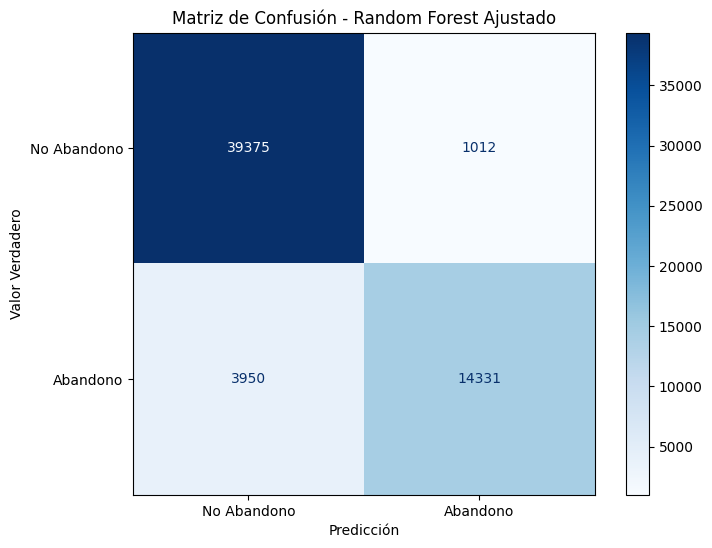

--- Visualización de la matriz de confusión completada. ---


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- Visualizando la matriz de confusión para el modelo Random Forest Ajustado ---")

# Obtener las predicciones y las etiquetas verdaderas del modelo ajustado
y_pred_tuned = model_results_full['Random Forest Tuned']['y_pred']
y_test = processed_data_full['y_test'] # Asegurarse de usar el y_test original

# Crear la matriz de confusión y visualizarla
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, ax=ax, cmap='Blues', display_labels=['No Abandono', 'Abandono'])
plt.title('Matriz de Confusión - Random Forest Ajustado')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.grid(False)
plt.show()

print("--- Visualización de la matriz de confusión completada. ---")

# **Almacenado del modelo Random Forest Tuned**

In [ ]:
import joblib

print("--- Guardando el modelo Random Forest ajustado ---")

# Obtener el modelo Random Forest ajustado del diccionario de resultados
best_rf_model_tuned = model_results_full['Random Forest Tuned']['model']

# Definir el nombre del archivo para guardar el modelo
model_filename = 'random_forest_tuned_model.joblib'

# Guardar el modelo en el archivo
joblib.dump(best_rf_model_tuned, model_filename)

print(f"El modelo Random Forest ajustado ha sido guardado exitosamente como '{model_filename}'.")

print("--- Guardado del modelo completado. ---")

--- Guardando el modelo Random Forest ajustado ---
El modelo Random Forest ajustado ha sido guardado exitosamente como 'random_forest_tuned_model.joblib'.
--- Guardado del modelo completado. ---


# **Descarga del modelo**

In [ ]:
from google.colab import files

# Nombre del archivo del modelo a descargar
model_filename = 'random_forest_tuned_model.joblib'

# Descargar el archivo
files.download(model_filename)

print(f"El archivo '{model_filename}' ha sido solicitado para descarga.")

# **Carga del modelo para nuevas predicciones**

In [ ]:
import joblib
import pandas as pd

print("--- Cargando el modelo Random Forest ajustado ---")

# Definir el nombre del archivo del modelo guardado
model_filename = 'random_forest_tuned_model.joblib'

# Cargar el modelo desde el archivo
loaded_rf_model = joblib.load(model_filename)

print(f"Modelo '{model_filename}' cargado exitosamente.")

print("--- Realizando una predicción de ejemplo ---")

# Recuperar los datos de prueba transformados y el preprocesador
X_test_transformed = processed_data_full['preprocessor'].transform(processed_data_full['X_test'])
y_test = processed_data_full['y_test']

# Tomar un ejemplo de los datos de prueba (la primera fila) para la predicción
sample_input_data = X_test_transformed[0:1]

# Realizar la predicción
prediction = loaded_rf_model.predict(sample_input_data)
prediction_proba = loaded_rf_model.predict_proba(sample_input_data)

print(f"Datos de entrada de ejemplo (primera fila de X_test_transformed):\n{sample_input_data}")

if prediction[0] == 1:
    print(f"La predicción para el ejemplo es: Abandono (Probabilidad: {prediction_proba[0][1]:.4f})")
else:
    print(f"La predicción para el ejemplo es: No Abandono (Probabilidad: {prediction_proba[0][0]:.4f})")

print(f"El valor real para este ejemplo (primera fila de y_test) es: {y_test.iloc[0]} ({'Abandono' if y_test.iloc[0] == 1 else 'No Abandono'})")

print("--- Demostración de predicción completada. ---")

--- Cargando el modelo Random Forest ajustado ---
Modelo 'random_forest_tuned_model.joblib' cargado exitosamente.
--- Realizando una predicción de ejemplo ---
Datos de entrada de ejemplo (primera fila de X_test_transformed):
[[-3.40403716e-01 -4.81078702e-01 -2.35910643e-01  1.34135786e+00
   1.00452781e+00  3.64461728e+00  7.20080738e-01  1.26782626e+00
  -1.53744485e-01  7.67178017e-01  1.02301007e+00  2.58810695e-01
   2.02196117e+00  1.77221894e-01 -9.52584000e-02 -1.08585990e-01
  -1.47135935e-01  2.33398655e+00  5.42382875e-01  6.86613785e-01
  -6.56142085e-02 -1.80601754e-01 -4.08647774e-01 -8.40232410e-02
  -1.31250078e-01 -1.71364732e-01 -1.54614820e-01 -9.36280140e-02
  -7.18131744e-02 -1.86719894e-02 -2.03036272e-01  3.15540598e+00
  -1.67044483e+00 -3.44999316e-03 -9.14829272e-02  3.48070873e-01
  -1.37592724e+00  1.47112710e+00  0.00000000e+00  1.00000000e+00
   1.00000000e+00  0.00000000e+00]]
La predicción para el ejemplo es: No Abandono (Probabilidad: 0.8535)
El valor r

# **Automatización de predicción para lotes de datos nuevos**

In [ ]:
import joblib
import pandas as pd

print("--- Automatizando la predicción para un lote de datos nuevos ---")

# 1. Cargar el modelo Random Forest ajustado
model_filename = 'random_forest_tuned_model.joblib'
loaded_rf_model = joblib.load(model_filename)
print(f"Modelo '{model_filename}' cargado exitosamente.")

# 2. Cargar el preprocesador que se usó durante el entrenamiento
# Este fue almacenado en processed_data_full
loaded_preprocessor = processed_data_full['preprocessor']
print("Preprocesador cargado exitosamente.")

# 3. Crear un lote de datos nuevos de ejemplo (simulados)
# Es CRÍTICO que los nuevos datos tengan las MISMAS COLUMNAS y el MISMO ORDEN
# que el DataFrame original 'X_current' antes del preprocesamiento.

# Usaremos las primeras 5 filas del X_test original como ejemplo de 'nuevos datos' en bruto.
# En un escenario real, esto provendría de una nueva fuente de datos.
new_raw_data = processed_data_full['X_test'].head(5).copy()
print("\n--- Lote de datos nuevos (raw) para la predicción ---")
print(new_raw_data)

# 4. Preprocesar los nuevos datos utilizando el preprocesador cargado
# Asegúrate de usar .transform() y no .fit_transform()
new_data_transformed = loaded_preprocessor.transform(new_raw_data)
print("\n--- Lote de datos nuevos (transformados) para la predicción ---")
print(new_data_transformed)

# 5. Realizar predicciones sobre los datos preprocesados
batch_predictions = loaded_rf_model.predict(new_data_transformed)
batch_probabilities = loaded_rf_model.predict_proba(new_data_transformed)

print("\n--- Resultados de la Predicción (Lote de Datos Nuevos) ---")
results_df = new_raw_data.copy()
results_df['Predicted_Dropout'] = batch_predictions
results_df['Probability_No_Dropout'] = batch_probabilities[:, 0]
results_df['Probability_Dropout'] = batch_probabilities[:, 1]

# Añadir el valor real de y_test para comparación (solo para demostración)
results_df['Actual_Dropout'] = processed_data_full['y_test'].head(5).values

print(results_df[['Actual_Dropout', 'Predicted_Dropout', 'Probability_Dropout']])

print("\n--- Automatización de predicción de lote completada. ---")

In [ ]:
print("--- Verificando la definición de processed_data_full['preprocessor'] ---")

if 'processed_data_full' in locals() and 'preprocessor' in processed_data_full:
    print("processed_data_full['preprocessor'] está definido y disponible.")
else:
    print("processed_data_full o la clave 'preprocessor' no están definidos. Asegúrate de ejecutar la celda '6. Balanceo de Clases con SMOTE' (ID: 5d1859fa) primero.")


--- Verificando la definición de processed_data_full['preprocessor'] ---
processed_data_full['preprocessor'] está definido y disponible.
